This notebook demonstrates how to load **panellinies_exams_dataset** from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from datasets import load_dataset
from dotenv import load_dotenv, find_dotenv

sys.path.append(os.path.abspath('..'))

from src.eda_utils import (
    # --- Data Presentation ---
    display_samples,
    print_sample, 
    display_qa,
    
    # --- Multimodal (Images) ---
    get_image_samples_df,
    display_multimodal_samples, 
    
    # --- Distributions & Plots ---
    plot_subject_dist,      
    plot_school_type_dist,       
    plot_format_dist,       
    plot_reference_dist,    
    plot_temporal_distribution,
    plot_format_by_subject,      
    
    # --- Points Analysis ---
    plot_points_distribution,
    plot_points_by_school_type, 
    plot_points_by_subject,     
    
    # --- Source Tracking ---
    print_source_files
)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")

c:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Repository: PennyK98/panellinies_exams_dataset


**1. Load the dataset**

In [3]:
dataset = load_dataset(repo_id, split="train", token=token, download_mode="force_redownload")
df = dataset.to_pandas()
#df = pd.read_excel("../results/panellinies_dataset.xlsx")

print(f"✅ Dataset loaded. Total rows: {len(df)}")

Generating train split: 100%|██████████| 1318/1318 [00:00<00:00, 22607.75 examples/s]

✅ Dataset loaded. Total rows: 1318


**2. Main samples inspection**

In [4]:
# Μαθηματικά, Φυσική, Χημεία, Βιολογία, Πληροφορική
science_df = df[df['subject'].isin(['mathematics', 'physics', 'chemistry', 'biology', 'computer_science'])]
all_science_ids = science_df['id'].tolist()
random_id_sc = random.choice(all_science_ids)

# Νεοελληνική Γλώσσα, Αρχαία, Ιστορία, Λατινικά, ΑΟΘ
humanities_df = df[df['subject'].isin(['greek_language', 'ancient_greek', 'history', 'latin', 'economics'])]
all_humanities_ids = humanities_df['id'].tolist()
random_id_hum = random.choice(all_humanities_ids)

# --- Στοχευμένα IDs ---
target_id = 'chemistry_gel_2020_Δ3.i'
#chemistry_gel_2020_Δ3.i 
#chemistry_gel_2020_Δ3.ii
#chemistry_gel_2024_Δ2.α
#chemistry_gel_2024_Δ3.α
#chemistry_gel_2024_Δ2.β
#chemistry_gel_2024_B2.α
#physics_gel_2025_Δ3
#physics_gel_2021_B3.β
test_id = 'ancient_greek_gel_2025_Α1.α.1'

# --- Τυχαίο δείγμα Θετικών ---
#display_qa(df, random_id_sc)
display_qa(df, target_id)

#print_source_files(df, sample_id=random_id_sc)
print_source_files(df, sample_id=target_id)

# --- Συγκεκριμένο δείγμα ---
display_qa(df, test_id)
print_source_files(df, sample_id=test_id)

🔍 Identifying source files for ID: chemistry_gel_2020_Δ3.i
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2020\GEL\ximeia\them_ximeia_gel_2020.json](..\data\2020\GEL\ximeia\them_ximeia_gel_2020.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2020\GEL\ximeia\apant_ximeia_gel_2020.md](..\data\2020\GEL\ximeia\apant_ximeia_gel_2020.md)

--------------------------------------------------


🔍 Identifying source files for ID: ancient_greek_gel_2025_Α1.α.1
📂 Searching in: C:\Users\panag\Desktop\ΙΕΛ ΕΡΓΑΣΙΑ\Εξετάσεις_γλωσσομάθειας\Πανελλήνιες\panellinies_exams_dataset\data
--------------------------------------------------


✅ **Source JSON:** [..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json](..\data\2025\GEL\arxaia\them_arxaia_gel_2025.json)

✅ **Source MD:** &nbsp;&nbsp; [..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md](..\data\2025\GEL\arxaia\apant_arxaia_gel_2025.md)

--------------------------------------------------


**3. Multimodal Analysis**

id,subject,format,reference,question,input,image,choices,answer_text,answer_index,image_description,image_transcription,points,year,school_type
biology_gel_2020_Δ4.i,biology,open_ended,multimodal,"Επιθυμούμε να κλωνοποιήσουμε το γονίδιο Α, χρησιμοποιώντας ως φορέα κλωνοποίησης το πλασμίδιο του Σχήματος 1. Διαθέτουμε τρεις διαφορετικές περιοριστικές ενδονουκλεάσες τις Ι, ΙΙ και EcoRI. Το πλασμίδιο φέρει γονίδιο ανθεκτικότητας στην αμπικιλίνη, γονίδιο ανθεκτικότητας στην στρεπτομυκίνη και δύο θέσεις αναγνώρισης από τις περιοριστικές ενδονουκλεάσες ΠΕ-Ι και ΠΕ-ΙΙ. Η περιοριστική ενδονουκλεάση I διαθέτει θέση αναγνώρισης μέσα στο γονίδιο ανθεκτικότητας της αμπικιλίνης, ενώ η περιοριστική ενδονουκλεάση ΙΙ διαθέτει θέση αναγνώρισης μέσα στο γονίδιο της στρεπτομυκίνης. Δίνονται οι αλληλουχίες έξι ζευγών βάσεων που αναγνωρίζουν και επιδρούν οι ΠΕ-Ι και ΠΕ-ΙΙ. Tα βέλη υποδεικνύουν τη θέση που δρα η κάθε περιοριστική ενδονουκλεάση (ΠΕ) στην αλληλουχία αναγνώρισης.Να γράψετε ποια ή ποιες ΠΕ θα χρησιμοποιηθούν για την κατασκευή του ανασυνδυασμένου πλασμιδίου.",,,,"Θα χρησιμοποιηθεί η περιοριστική ενδονουκλεάση EcoRI, καθώς το γονίδιο Α φέρει θέσεις αναγνώρισης γι' αυτό το ένζυμο στα άκρα του.",,"Figure 4: A circular diagram representing a plasmid containing two antibiotic resistance genes. Inside the plasmid, two regions are labeled: «Γονίδιο ανθεκτικότητας στην αμπικιλίνη» and «Γονίδιο ανθεκτικότητας στη στρεπτομυκίνη». Two specific sites on the plasmid are indicated on the outer ring with arrows labeled I and II, marking distinct positions on the DNA molecule. The diagram illustrates the location of resistance genes and specific sites within the plasmid. | Figure 5: A diagram showing two restriction enzyme recognition sites labeled ΠΕ-I and ΠΕ-II. Arrows indicate the cleavage positions within the sequences.","Γονίδιο ανθεκτικότητας στην αμπικιλίνη, Γονίδιο ανθεκτικότητας στη στρεπτομυκίνη, I, II",2.0,2020,GEL
physics_gel_2024_B3.α.β,physics,open_ended,multimodal,"Το σώμα $\Sigma$ του παρακάτω σχήματος, μάζας $m$, έχει στερεωθεί στο άκρο Β οριζόντιας, ομογενούς, άκαμπτης και αβαρούς ράβδου ΑΒ. Η ράβδος ακουμπά πάνω στην περιφέρεια ομογενούς δίσκου κέντρου Ο και ακτίνας $R$. Ο δίσκος βρίσκεται πάνω σε οριζόντιο επίπεδο με το επίπεδό του κατακόρυφο. Το σώμα $\Sigma$ μπορεί να κινείται πάνω σε λεία, οριζόντια, ομογενή και άκαμπτη δοκό ΓΔ μήκους $\ell$ και μάζας $M = m/2$.Η δοκός έχει αρθρωθεί κατάλληλα στο σημείο Z, με την κορυφή κατακόρυφου και ακλόνητου υποστηρίγματος (1) που βρίσκεται σε απόσταση $\ell/4$ από το άκρο της Γ. Σε απόσταση $\ell/4$ από το άκρο Δ της δοκού έχει τοποθετηθεί ένα δεύτερο, όμοιο κατακόρυφο υποστήριγμα (2), πάνω στην κορυφή Λ του οποίου ακουμπά η δοκός ΓΔ. Τα υποστηρίγματα έχουν τοποθετηθεί στο ίδιο οριζόντιο επίπεδο με αυτό στο οποίο βρίσκεται ο δίσκος, όπως φαίνεται στο σχήμα.Το σύστημα ράβδου-σώματος $\Sigma$ κινείται προς τα αριστερά με σταθερή ταχύτητα μέτρου $\upsilon$. Ο δίσκος εκτελεί κύλιση χωρίς ολίσθηση και η περιφέρειά του βρίσκεται σε συνεχή επαφή με τη ράβδο ΑΒ, χωρίς να παρατηρείται ολίσθηση μεταξύ τους.Το σώμα $\Sigma$, κινούμενο από το Δ προς το Γ, τη χρονική στιγμή $t = 0$ περνά από το μέσο Η της δοκού. Τη χρονική στιγμή $t_1$ το σώμα $\Sigma$ περνά από ένα σημείο της δοκού, στο οποίο η δοκός μόλις που χάνει οριακά την επαφή της με την κορυφή του υποστηρίγματος (2).Η απόσταση που έχει διανύσει το σώμα $\Sigma$ από τη χρονική στιγμή $t = 0$ μέχρι τη χρονική στιγμή $t_1$ είναι: i. $\frac{5\ell}{6}$ ii. $\frac{3\ell}{8}$ iii. $\frac{\ell}{3}$ Να επιλέξετε τη σωστή απάντηση και να δικαιολογήσετε την επιλογή σας.",,,,"Σωστή απάντηση η (ii)Στο κιβώτιο m ασκούνται, το βάρος του $W_m$ και η δύναμη από την ράβδο $N_m$.Από την ισορροπία του κιβωτίου στον άξονα y'y: $\Sigma F_y = 0$ ή $N_m = mg$Από τον 3ο νόμο του Νεύτωνα, στη ράβδο ασκείται η $N_m'$ ($N_m' = N_m = mg$)Την στιγμή που η ράβδος ΓΔ χάνει την επαφή της από το υποστήριγμα (2): $N_2 = 0$Προφανώς εκείνη την στιγμή το σώμα Σ είναι αριστερά του Ζ κα
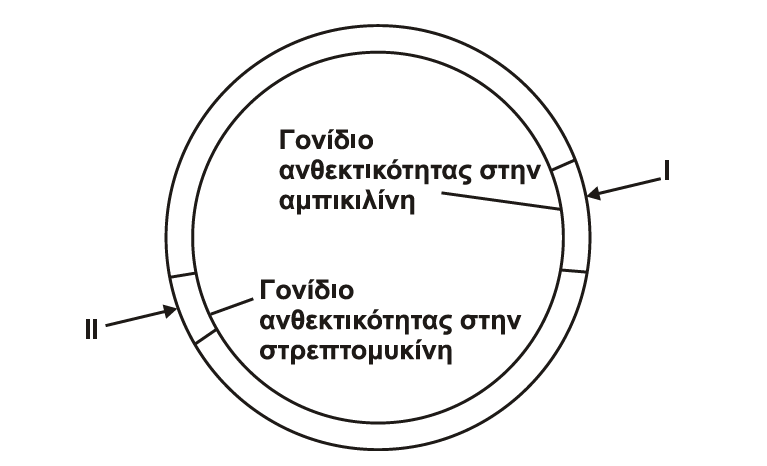
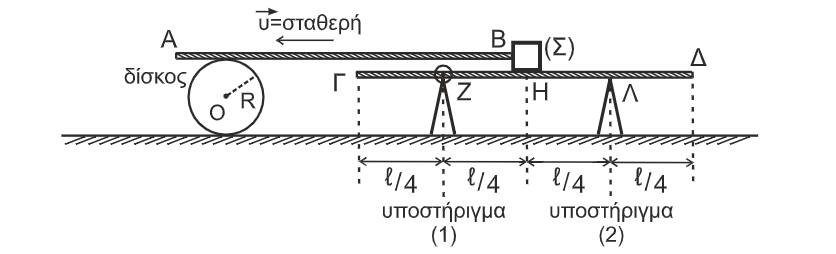
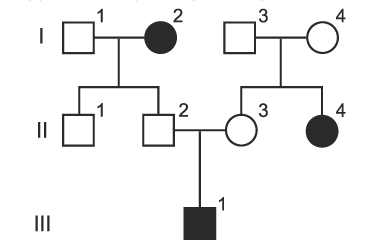

In [6]:
display_samples(df, n=3, prioritize_images=True)

4.1 Distribution by Subject and School Type

In [ ]:
# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

In [ ]:
# School Type Distribution
fig_school, df_school = plot_school_type_dist(df)
display(df_school)
display(fig_school)

4.2 Distribution by Format and Reference Type

In [ ]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

In [ ]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

4.3 Temporal Trends

In [ ]:
# Temporal Trends (Distribution over years per subject)
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

4.4 Point Values & Format Analysis

In [ ]:
# Points Distribution
fig_points, df_points = plot_points_distribution(df)
display(df_points)
if fig_points is not None:
    display(fig_points)

In [ ]:
# Points by School Type 
fig_pts_school, df_pts_school = plot_points_by_school_type(df)
display(df_pts_school)
if fig_pts_school is not None:
    display(fig_pts_school)

In [ ]:
# Points by Subject
fig_pts_subj, df_pts_subj = plot_points_by_subject(df)
display(df_pts_subj)
if fig_pts_subj is not None:
    display(fig_pts_subj)

In [ ]:
# Format by Subject
fig_fmt, df_fmt = plot_format_by_subject(df)
display(df_fmt)
display(fig_fmt)

4.5 Unique verification

In [ ]:
# 1. Μετατρέπουμε προσωρινά τις λίστες (choices) σε tuples για να μπορούν να συγκριθούν
if 'choices' in df.columns:
    choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
else:
    choices_hashable = None

# 2. Έλεγχος μοναδικότητας του 'id'
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")

# 3. Έλεγχος για ερωτήσεις με ολόιδιο περιεχόμενο (Question + Input)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns: subset_to_check.append('input')

if subset_to_check:
    content_duplicates = df.duplicated(subset=subset_to_check).sum()
    print(f"Rows with identical content (Question/Input): {content_duplicates}")
    
    # Αν βρει διπλότυπα, τα τυπώνει για να τα δεις
    if content_duplicates > 0:
        print("\nDisplaying samples of content duplicates:")
        dup_rows = df[df.duplicated(subset=subset_to_check, keep=False)]
        display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question']])

# 4. Έλεγχος για κενές τιμές (nulls) σε κρίσιμες στήλες
critical_cols = ['id', 'subject', 'school_type', 'question', 'format']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\n⚠️ Null values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

In [ ]:
# 1. Βρίσκει γραμμές που έχουν το κυριολεκτικό '\n' (ως κείμενο)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()

# 2. Βρίσκει γραμμές που είναι λίστες μετατρεπόμενες σε strings π.χ. "['a', 'b']"
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()

# 3. Βρίσκει τις "σωστές" απαντήσεις που έχουν πραγματικές αλλαγές γραμμής
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()

print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
if literal_nl_ids: print(f"IDs: {literal_nl_ids[:10]} ...\n")

print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
if json_list_ids: print(f"IDs: {json_list_ids[:10]} ...\n")

print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
if true_multiline_ids: print(f"IDs: {true_multiline_ids[:10]} ...")

In [ ]:
from IPython.display import Markdown

# Φορτώνουμε το dataset απευθείας από το Hugging Face
dataset = load_dataset(repo_id, split="train", token=token)

# Διάλεξε ένα δικό σου ID για τεστ
target_id = "ancient_greek_gel_2025_Α1.α.1" 

subset = dataset.filter(lambda x: x["id"] == target_id)

if len(subset) > 0:
    sample = subset[0]
    
    md_output = f"### ID: {sample['id']}\n"
    md_output += f"**Question:** {sample['question']}\n\n"
    
    if sample.get('input'):
        md_output += f"**Input:**\n{sample['input']}\n\n"
        
    if sample.get('images'):
        md_output += f"🖼️ **Images Attached:** {len(sample['images'])}\n\n"
        
    if sample.get('choices'):
        md_output += "#### Choices:\n"
        correct_idx = sample.get('answer_index')
        for i, choice in enumerate(sample['choices']):
            marker = "✅" if i == correct_idx else "⬜"
            md_output += f"- [{marker}] **{i}**: {choice}\n"
        md_output += f"\n**Correct Answer Index:** `{correct_idx}`"
    else:
        md_output += f"\n**Answer:**\n{sample['answer_text']}"
        
    display(Markdown(md_output))
else:
    print(f"ID {target_id} not found in Hugging Face dataset.")